<a href="https://colab.research.google.com/github/sophia-yang424/aca_chemprop/blob/main/my_pipeline_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 2. Clone the repo or download it
!git clone https://github.com/chemprop/chemprop_benchmark_v2.git
%cd chemprop_benchmark_v2

# 3. Clean up any corrupted files, then download and extract the data properly
!rm -rf data.tar.gz data/
!wget https://zenodo.org/records/10078142/files/data.tar.gz
!tar -xzvf data.tar.gz

Cloning into 'chemprop_benchmark_v2'...
remote: Enumerating objects: 698, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 698 (delta 161), reused 95 (delta 57), pack-reused 460 (from 1)
Receiving objects: 100% (698/698), 441.81 KiB | 8.50 MiB/s, done.
Resolving deltas: 100% (498/498), done.
/content/chemprop_benchmark_v2/chemprop_benchmark_v2
--2026-09-12 03:04:47--  https://zenodo.org/records/10078142/files/data.tar.gz
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1632346035 (1.5G) [application/octet-stream]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>]   1.52G  50.5MB/s    in 30s     

2026-09-12 03:05:17 (51.7 MB/s) - ‘data.tar.gz’ saved [1632346035/1632346035]

data/
data/barriers_sn2/
data/barriers_sn2/test.csv
dat

In [6]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.metrics import r2_score
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from chemprop import data, featurizers, models, nn as cp_nn
from chemprop.data.splitting import make_split_indices, split_data_by_indices

import warnings
warnings.filterwarnings('ignore')

In [5]:
%pip install -q chembl_webresource_client rdkit chemprop optuna tqdm lightning scikit-learn seaborn optuna-integration[pytorch_lightning]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 171.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd

# Load the split data directly from the CSV files
train_df = pd.read_csv('data/barriers_sn2/train.csv')
val_df = pd.read_csv('data/barriers_sn2/val.csv')
test_df = pd.read_csv('data/barriers_sn2/test.csv')

print(f"Test: {len(test_df)}, Train: {len(train_df)}, Val: {len(val_df)}")
# Expected Output: Test: 4113, Train: 32901, Val: 4113 (based on typical dataset sizes)

Test: 561, Train: 1440, Val: 360


In [11]:

import sys
from rdkit import RDLogger

# Suppress RDKit warnings
lg = RDLogger.logger()
lg.setLevel(RDLogger.ERROR)

for key in list(sys.modules.keys()):
    if key.startswith('torchvision'):
        del sys.modules[key]


# 1. Build datapoints directly from the explicitly loaded DataFrames
def build_reaction_datapoints(df, smiles_col='AAM', label_col='ea'):
    smis = df[smiles_col].tolist()
    ys = df[[label_col]].values
    # Use ReactionDatapoint since these are reaction SMILES with '>>'
    return [data.ReactionDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]

print("Building datasets from explicit splits...")
train_data = build_reaction_datapoints(train_df)
val_data = build_reaction_datapoints(val_df)
test_data = build_reaction_datapoints(test_df)

# 2. Build Datasets & scale targets
# Use the default featurizer for ReactionDataset to properly handle reaction tuples
train_dset = data.ReactionDataset(train_data)
val_dset = data.ReactionDataset(val_data)
test_dset = data.ReactionDataset(test_data)

target_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(target_scaler)
test_dset.normalize_targets(target_scaler)

# 3. Build Dataloaders
train_loader = data.build_dataloader(train_dset, num_workers=0, shuffle=True)
val_loader = data.build_dataloader(val_dset, num_workers=0, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=0, shuffle=False)
train_loader_eval = data.build_dataloader(train_dset, num_workers=0, shuffle=False)

pl.seed_everything(42, workers=True)

# Dynamically extract feature dimensions from the dataloader for Reaction graphs
sample_batch = next(iter(train_loader))
# Handle both .v/.e and .V/.E attribute naming conventions just in case
d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]
print(f"Extracted feature dimensions: d_v={d_v}, d_e={d_e}")

# 4. Define Model with extracted hyperparameters (max_lr = 0.001)
hidden_size = 300
output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

# Pass the dynamically extracted dimensions into the message passing block
mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
agg = cp_nn.MeanAggregation()
ffn = cp_nn.RegressionFFN(
    input_dim=hidden_size,
    output_transform=output_transform,
    dropout=0.15,
)
mpnn = models.MPNN(
    mp, agg, ffn,
    batch_norm=True,
    metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
    warmup_epochs=2,
    init_lr=1e-4,
    max_lr=0.001,
    final_lr=1e-4,
) #hyperparamters i got from the chemprop run itself when it searched

# 5. Train
early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True,
    callbacks=[early_stop, checkpoint],
)

print("\nTraining custom pipeline on explicit splits...")
trainer.fit(mpnn, train_loader, val_loader)

# 6. Evaluate
best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
mpnn.load_state_dict(best_ckpt['state_dict'])
mpnn.eval()

def get_r2(loader, true_data):
    preds = trainer.predict(mpnn, loader)
    y_pred = torch.cat(preds).numpy().flatten()
    y_true = np.array([d.y[0] for d in true_data])
    return r2_score(y_true, y_pred)

r2_test = get_r2(test_loader, test_data)
r2_train = get_r2(train_loader_eval, train_data)

print(f"\n=== Custom Pipeline Final Results (barriers_sn2) ===")
print(f"Train R^2: {r2_train:.4f}")
print(f"Test R^2:  {r2_test:.4f}")


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

Building datasets from explicit splits...
Extracted feature dimensions: d_v=106, d_e=28

Training custom pipeline on explicit splits...


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  252 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 343 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 343 K                                                                                                
Total estimated model params size (MB): 1.374                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


=== Custom Pipeline Final Results (barriers_sn2) ===
Train R^2: 0.9403
Test R^2:  0.9171


on molecule ace benchmark

In [15]:
!pip install -q chemprop lightning
!pip install -q chembl_webresource_client python-Levenshtein torch-geometric
!pip install -q --no-deps MoleculeACE

KeyboardInterrupt: 

In [16]:
!pip install rdkit-pypi pandas numpy pandas chembl_webresource_client scikit-learn matplotlib tqdm python-Levenshtein

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


getting baseline for molecule ace benchmark data from moleculeAce paper using our chemprop gnn training pipeline BEFORE loss function modifcations. we used a custom pytorch training pipeline instead of chemprops built in trainer because the latter wouldnt let you touch the loss function used which we will chnage later:
below you will see a training cell that trains both for mixed aca and isolated aca (2 function callss of training fucniton we define)

In [17]:
from MoleculeACE import Data, datasets
import pandas as pd

# View all available datasets
print(datasets)  # 30 datasets from the benchmark study

# Load any dataset (e.g., CHEMBL2034_Ki - Glucocorticoid receptor)
data = Data('CHEMBL2034_Ki')

# Access the data
smiles_train = data.smiles_train
y_train = data.y_train

smiles_test = data.smiles_test
y_test = data.y_test

# Save to CSV if needed
train_df = pd.DataFrame({'smiles': smiles_train, 'y': y_train})
test_df = pd.DataFrame({'smiles': smiles_test, 'y': y_test})
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

['CHEMBL4203_Ki', 'CHEMBL2034_Ki', 'CHEMBL233_Ki', 'CHEMBL4616_EC50', 'CHEMBL287_Ki', 'CHEMBL218_EC50', 'CHEMBL264_Ki', 'CHEMBL219_Ki', 'CHEMBL2835_Ki', 'CHEMBL2147_Ki', 'CHEMBL231_Ki', 'CHEMBL3979_EC50', 'CHEMBL237_EC50', 'CHEMBL244_Ki', 'CHEMBL4792_Ki', 'CHEMBL1871_Ki', 'CHEMBL237_Ki', 'CHEMBL262_Ki', 'CHEMBL2047_EC50', 'CHEMBL239_EC50', 'CHEMBL2971_Ki', 'CHEMBL204_Ki', 'CHEMBL214_Ki', 'CHEMBL1862_Ki', 'CHEMBL234_Ki', 'CHEMBL238_Ki', 'CHEMBL235_EC50', 'CHEMBL4005_Ki', 'CHEMBL236_Ki', 'CHEMBL228_Ki']


In [18]:
from MoleculeACE import Data

data = Data('CHEMBL2034_Ki')

# Get only activity cliff compounds
cliff_indices = [i for i, cliff in enumerate(data.cliff_mols_test) if cliff == 1]
cliff_smiles = [data.smiles_test[i] for i in cliff_indices]
cliff_y = [data.y_test[i] for i in cliff_indices]

print(f"Total test: {len(data.smiles_test)}")
print(f"Cliff test: {len(cliff_smiles)}")

Total test: 152
Cliff test: 52


In [ ]:
!git clone https://github.com/molML/MoleculeACE.git

In [19]:
from sklearn.model_selection import train_test_split
from MoleculeACE import Data
import numpy as np

mac_data = Data('CHEMBL2034_Ki')

# --- 1. FULL DATA SPLITS ---
smiles_train_full = mac_data.smiles_train
y_train_full = mac_data.y_train
smiles_test_full = mac_data.smiles_test
y_test_full = mac_data.y_test

# Split train into train and val (85/15)
smiles_tr_full, smiles_val_full, y_tr_full, y_val_full = train_test_split(
    smiles_train_full, y_train_full, test_size=0.15, random_state=42
)

# --- 2. ACTIVITY CLIFF ONLY SPLITS ---
# Get indices of cliff compounds
cliff_tr_idx = [i for i, c in enumerate(mac_data.cliff_mols_train) if c == 1]
cliff_te_idx = [i for i, c in enumerate(mac_data.cliff_mols_test) if c == 1]

smiles_cliff_train = [mac_data.smiles_train[i] for i in cliff_tr_idx]
y_cliff_train = [mac_data.y_train[i] for i in cliff_tr_idx]
smiles_cliff_test = [mac_data.smiles_test[i] for i in cliff_te_idx]
y_cliff_test = [mac_data.y_test[i] for i in cliff_te_idx]

# Split cliff train into train and val (85/15)
smiles_tr_cliff, smiles_val_cliff, y_tr_cliff, y_val_cliff = train_test_split(
    smiles_cliff_train, y_cliff_train, test_size=0.15, random_state=42
)

print(f"Full Data - Train: {len(smiles_tr_full)}, Val: {len(smiles_val_full)}, Test: {len(smiles_test_full)}")
print(f"Cliff Data - Train: {len(smiles_tr_cliff)}, Val: {len(smiles_val_cliff)}, Test: {len(smiles_cliff_test)}")

Full Data - Train: 508, Val: 90, Test: 152
Cliff Data - Train: 169, Val: 30, Test: 52


In [20]:
#setting datapoints up (getting the one hot features from the smile strings for input + settingup training function)
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch
from sklearn.metrics import r2_score

def train_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Build datapoints (MoleculeDatapoint since these are single molecules, not reactions)
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(42, workers=True)

    # Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # Define Model
    hidden_size = 300
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
    agg = cp_nn.MeanAggregation()
    ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=0.15)

    mpnn = models.MPNN(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2, init_lr=1e-4, max_lr=0.001, final_lr=1e-4,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=True, callbacks=[early_stop, checkpoint],
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # Evaluate
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()
    r2_test = r2_score(y_te, y_pred)

    print(f"\n>>> {model_name} Final Test R^2: {r2_test:.4f} <<<")
    return mpnn, trainer, test_loader

In [21]:
# Train on FULL MoleculeACE dataset
mpnn_full, trainer_full, test_loader_full = train_chemprop_model(
    smiles_tr_full, y_tr_full,
    smiles_val_full, y_val_full,
    smiles_test_full, y_test_full,
    "Model 1: Full CHEMBL2034_Ki Data"
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_fl


Training Model 1: Full CHEMBL2034_Ki Data


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). 

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/saving.py:398: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.



>>> Model 1: Full CHEMBL2034_Ki Data Final Test R^2: 0.4150 <<<


In [22]:
# Train on ACTIVITY CLIFF compounds ONLY
mpnn_cliff, trainer_cliff, test_loader_cliff = train_chemprop_model(
    smiles_tr_cliff, y_tr_cliff,
    smiles_val_cliff, y_val_cliff,
    smiles_cliff_test, y_cliff_test,
    "Model 2: Activity Cliff Compounds Only"
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Training Model 2: Activity Cliff Compounds Only


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/saving.py:398: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.



>>> Model 2: Activity Cliff Compounds Only Final Test R^2: 0.0687 <<<


In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 37.2 MB/s eta 0:00:00


In [ ]:
#hyperparam search first for entire data set (mixed w ac and not ac molecules) + isolated ac molecules
import optuna
import lightning.pytorch as pl
from chemprop import data as cp_data, models, nn as cp_nn
from lightning.pytorch.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

def optimize_hyperparams_full(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        # 1. Define hyperparameters using continuous ranges
        hidden_size = trial.suggest_int("hidden_size", 50, 300) # Range instead of fixed list
        depth = trial.suggest_int("depth", 2, 6)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-4, 1e-2, log=True)

        # 2. Setup Data
        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        # 3. Model Architecture (DEFINED INSIDE SO EACH TRIAL GETS A FRESH MODEL)
        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        # 4. Training
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    # Run the hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study.best_params

#HYPERPARAM SEARCH 1: FULL (MIXED AC + NON AC MOLECULE DATA)
best_params_full = optimize_hyperparams_full(
    smiles_tr_full, y_tr_full, smiles_val_full, y_val_full,
    study_name="Full CHEMBL2034_Ki Data", n_trials=100
)
#notice here we define the set of foud paramters as best_params_full. for the isolated, we define the found set for that data under diff name
#so when we train later on with our found paramters, these wont conflict, we have distinguished these two sets from each other

#^THE ABOVE (and below for only ac) SEARCHES WILL TRAIN YOUR MODEL BUT WONT SAVE THEM FOR SPACE SINCE IT SEARCHES + TRAINS SO MANY
#TO ACTUALLY SAVE THE MODEL WITH THE HYPERPARAMTERS, WE TRAIN AGAIN FROM SCRACTH BELOW with our found optumal hyperparamters from optuna, REPORDUCIBLE SINCE WE USE THE SAME SEED 42


In [ ]:
# HYPERPARAMETER SEARCH 2: ISOLATED (ONLY AC MOLECULE DATA)

def optimize_hyperparams_cliff(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        # 1. Define hyperparameters using restrictive continuous ranges for small data
        hidden_size = trial.suggest_int("hidden_size", 50, 300) # Range instead of fixed list
        depth = trial.suggest_int("depth", 2, 3)
        dropout = trial.suggest_float("dropout", 0.3, 0.7)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-4, 1e-2, log=True)

        # 2. Setup Data
        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        # 3. Model Architecture
        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        # 4. Training
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    # Run the hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study.best_params

# Run on Activity Cliff Only Dataset
best_params_cliff = optimize_hyperparams_cliff(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff,
    study_name="Activity Cliff Compounds Only", n_trials=100
)


In [76]:
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

def train_tuned_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name, best_params):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Build datapoints and datasets
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(42, workers=True)

    # 2. Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # 3. Define Model using OPTUNA best parameters
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(
        d_v=d_v, d_e=d_e,
        d_h=best_params["hidden_size"],
        depth=best_params["depth"]
    )
    agg = cp_nn.MeanAggregation()
    ffn = cp_nn.RegressionFFN(
        input_dim=best_params["hidden_size"],
        output_transform=output_transform,
        dropout=best_params["dropout"]
    )

    mpnn = models.MPNN(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2,
        init_lr=best_params["init_lr"],
        max_lr=best_params["max_lr"],
        final_lr=best_params["init_lr"],
    )

    # 4. Train - Relaxed early stopping criteria
    early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", min_delta=0.001)
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    # Use CSVLogger to track train and val losses per epoch
    logger = CSVLogger("logs", name=model_name.replace(" ", "_").replace(":", ""))

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=False,
        logger=logger,
        callbacks=[early_stop, checkpoint],
        deterministic=True  # Force deterministic GPU operations
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # 5. Evaluate best model
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    best_epoch = best_ckpt.get('epoch', 'Unknown')
    best_val_loss = checkpoint.best_model_score.item() if checkpoint.best_model_score is not None else float('nan')
    print(f"\n[INFO] Loaded Best Model Checkpoint from Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()

    r2_test = r2_score(y_te, y_pred)
    mse_test = mean_squared_error(y_te, y_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_te, y_pred)

    print(f"\n>>> {model_name} Final Test Results <<<")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Test R^2:      {r2_test:.4f}")
    print(f"Test MSE:      {mse_test:.4f}")
    print(f"Test RMSE:     {rmse_test:.4f}")
    print(f"Test MAE:      {mae_test:.4f}")

    metrics_dict = {
        "val_loss_best": best_val_loss,
        "r2": r2_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "mae": mae_test
    }

    metrics_file = f"{logger.save_dir}/{logger.name}/version_{logger.version}/metrics.csv"

    # 6. Plot Learning Curve Automatically
    try:
        df = pd.read_csv(metrics_file)
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))
        if "train_loss" in df_agg.columns:
            plt.plot(df_agg["epoch"], df_agg["train_loss"], label="Train Loss", marker="o", markersize=4)
        if "val_loss" in df_agg.columns:
            plt.plot(df_agg["epoch"], df_agg["val_loss"], label="Val Loss", marker="s", markersize=4)

        plt.title(f"Learning Curve: {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot curves: {e}")

    return mpnn, trainer, test_loader, metrics_dict, metrics_file


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

Training tuned models...

Training Tuned Model: Full CHEMBL2034_Ki Data


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 62.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    284 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 43.2 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 106 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 106 K                                                                                                
Total estimated model params size (MB): 0.426                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 20 (Val Loss: 0.4165)

>>> Tuned Model: Full CHEMBL2034_Ki Data Final Test Results <<<
Best Val Loss: 0.4165
Test R^2:      0.4005
Test MSE:      0.6049
Test RMSE:     0.7777
Test MAE:      0.5725


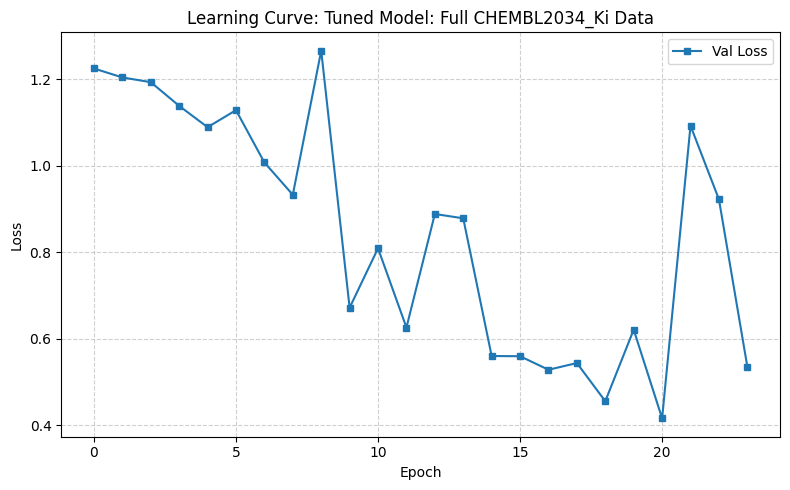

In [57]:
# --- Train Tuned Baselines ---
#train model w ideal params for mixed (aka using best_params_full)
print("Training tuned models...")
_, _, _, metrics_dict_full, metrics_full = train_tuned_chemprop_model(
    smiles_tr_full, y_tr_full, smiles_val_full, y_val_full, smiles_test_full, y_test_full,
    "Tuned Model: Full CHEMBL2034_Ki Data", best_params_full
)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Training Tuned Model: Activity Cliff Compounds Only


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  147 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    470 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 71.1 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 219 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 219 K                                                                                                
Total estimated model params size (MB): 0.878                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 21 (Val Loss: 0.5093)

>>> Tuned Model: Activity Cliff Compounds Only Final Test Results <<<
Best Val Loss: 0.5093
Test R^2:      -0.0734
Test MSE:      0.9253
Test RMSE:     0.9619
Test MAE:      0.7769


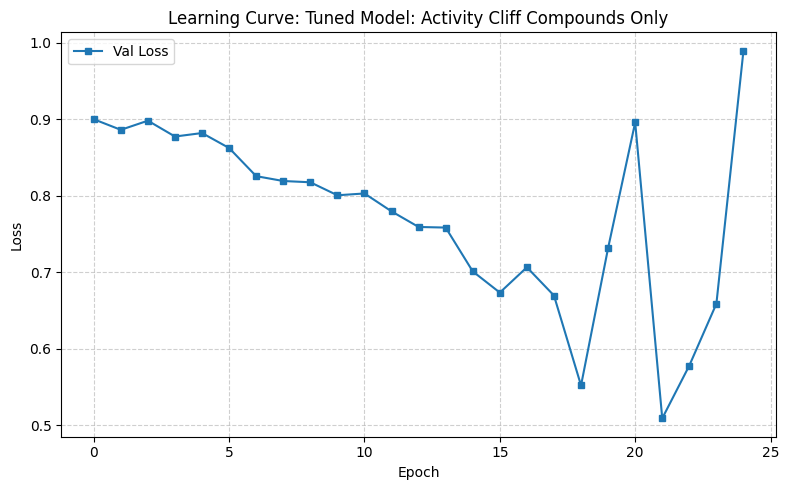

In [58]:
#train model w ideal params for isolated
_, _, _, metrics_dict_cliff, metrics_cliff = train_tuned_chemprop_model(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff, smiles_cliff_test, y_cliff_test,
    "Tuned Model: Activity Cliff Compounds Only", best_params_cliff
)


--- Overfitting Check: Best Hyperparameters ---


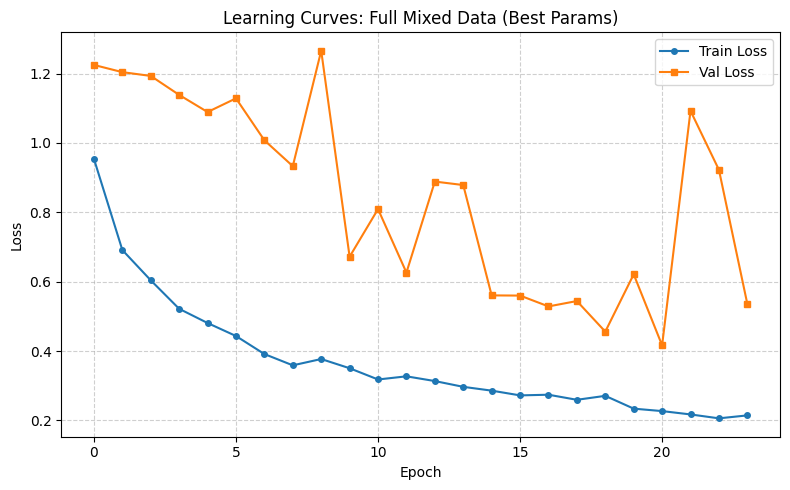

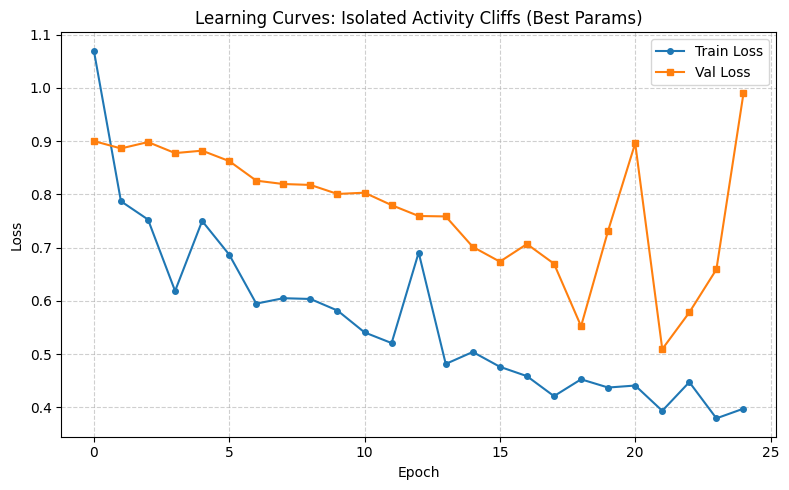

In [59]:
#plots of learning curves for final parameters we used ot teian ours (not optuna)
# plots of the models for AFTER optuna right, like the ones after we used the selected set of optimal params
import pandas as pd
import matplotlib.pyplot as plt

def plot_learning_curves(metrics_csv, title):
    try:
        df = pd.read_csv(metrics_csv)
        # Group by epoch to handle staggered train/val logging steps
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))

        # Dynamically find the train and val loss column names
        train_cols = [c for c in df_agg.columns if 'train' in c.lower() and 'loss' in c.lower()]
        val_cols = [c for c in df_agg.columns if 'val' in c.lower() and 'loss' in c.lower()]

        if train_cols:
            # Drop NaNs just in case logging steps don't perfectly align
            t_data = df_agg[['epoch', train_cols[0]]].dropna()
            plt.plot(t_data["epoch"], t_data[train_cols[0]], label="Train Loss", marker="o", markersize=4)

        if val_cols:
            v_data = df_agg[['epoch', val_cols[0]]].dropna()
            plt.plot(v_data["epoch"], v_data[val_cols[0]], label="Val Loss", marker="s", markersize=4)

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot {title}: {e}")

print("--- Overfitting Check: Best Hyperparameters ---")
plot_learning_curves(metrics_full, "Learning Curves: Full Mixed Data (Best Params)")
plot_learning_curves(metrics_cliff, "Learning Curves: Isolated Activity Cliffs (Best Params)")

### 3. Non-Activity Cliff (Normal) Compounds
Let's isolate the 'normal' compounds to see how well the model handles a smooth SAR landscape compared to the sharp activity cliffs. Above we evalauted chemprop on 1. the mixed data ac and non ac and 2. only ac data. lets look at third case (only non ac)

In [64]:
# --- 1. NON-ACTIVITY CLIFF SPLITS ---
# Get indices of non-cliff compounds (where cliff == 0)
non_cliff_tr_idx = [i for i, c in enumerate(mac_data.cliff_mols_train) if c == 0]
non_cliff_te_idx = [i for i, c in enumerate(mac_data.cliff_mols_test) if c == 0]

smiles_non_cliff_train = [mac_data.smiles_train[i] for i in non_cliff_tr_idx]
y_non_cliff_train = [mac_data.y_train[i] for i in non_cliff_tr_idx]
smiles_non_cliff_test = [mac_data.smiles_test[i] for i in non_cliff_te_idx]
y_non_cliff_test = [mac_data.y_test[i] for i in non_cliff_te_idx]

# Split non-cliff train into train and val (85/15)
smiles_tr_non_cliff, smiles_val_non_cliff, y_tr_non_cliff, y_val_non_cliff = train_test_split(
    smiles_non_cliff_train, y_non_cliff_train, test_size=0.15, random_state=42
)

print(f"Non-Cliff Data - Train: {len(smiles_tr_non_cliff)}, Val: {len(smiles_val_non_cliff)}, Test: {len(smiles_non_cliff_test)}")

Non-Cliff Data - Train: 339, Val: 60, Test: 100


In [73]:
# --- 2. HYPERPARAMETER SEARCH FOR NON-CLIFF DATA ---
import optuna
import lightning.pytorch as pl
from chemprop import data as cp_data, models, nn as cp_nn
from lightning.pytorch.callbacks import EarlyStopping

def optimize_hyperparams_non_cliff(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=50):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        # Expanded capacity to prevent underfitting
        hidden_size = trial.suggest_int("hidden_size", 100, 400)
        depth = trial.suggest_int("depth", 3, 5) # Deeper network for smooth SAR
        dropout = trial.suggest_float("dropout", 0.05, 0.25) # Lower dropout!
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-5, 5e-3, log=True) #drop lb down because the prev optuna results chose bestto tbe lower end, landed at max_lr=1.58e-4, right near the floor of my initial 1e-4 to 5e-3 range.
       # max_lr = trial.suggest_float("max_lr", 1e-4, 5e-3, log=True)

        # Setup Data
        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        # Model Architecture
        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        # Training
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    # Run the hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study.best_params

# Run with the NEW search parameters suited for smoother data
best_params_non_cliff = optimize_hyperparams_non_cliff(
    smiles_tr_non_cliff, y_tr_non_cliff,
    smiles_val_non_cliff, y_val_non_cliff,
    study_name="Non-Activity Cliff Compounds",
    n_trials=100
)

[I 2026-09-14 02:42:51,175] A new study created in memory with name: no-name-2fbbfdab-1474-4a6b-86b5-239f8c1bd65f
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)


Starting Optuna Hyperparameter Search for: Non-Activity Cliff Compounds


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 54.5 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    260 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 39.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 94.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 94.3 K                                                                                               
Total estimated model params size (MB): 0.377                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-14 02:42:55,962] Trial 0 finished with value: 0.5935476422309875 and parameters: {'hidden_size': 130, 'depth': 5, 'dropout': 0.20596381666726232, 'init_lr': 3.5532689977761725e-05, 'max_lr': 0.00028535131300305526}. Best is trial 0 with value: 0.5935476422309875.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatical

...

[I 2026-09-14 02:49:21,451] Trial 98 finished with value: 0.5528515577316284 and parameters: {'hidden_size': 156, 'depth': 3, 'dropout': 0.13803356281442153, 'init_lr': 1.2388160374377228e-05, 'max_lr': 0.0015268578792713115}. Best is trial 51 with value: 0.44029349088668823.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatic

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 69.6 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    302 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 45.9 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 115 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 115 K                                                                                                
Total estimated model params size (MB): 0.463                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-14 02:49:25,613] Trial 99 finished with value: 0.5325722694396973 and parameters: {'hidden_size': 151, 'depth': 3, 'dropout': 0.15174340338890382, 'init_lr': 1.567060545415627e-05, 'max_lr': 0.000730175847399231}. Best is trial 51 with value: 0.44029349088668823.



=== Best Hyperparameters for Non-Activity Cliff Compounds ===
{'hidden_size': 179, 'depth': 3, 'dropout': 0.14325763295083002, 'init_lr': 1.0391097111495258e-05, 'max_lr': 0.0005189506922300196}
Best Val Loss: 0.44029349088668823



INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Training Tuned Model: Non-Activity Cliff Compounds


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 92.5 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    358 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 54.3 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 147 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 147 K                                                                                                
Total estimated model params size (MB): 0.589                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 19 (Val Loss: 0.4968)

>>> Tuned Model: Non-Activity Cliff Compounds Final Test Results <<<
Best Val Loss: 0.4968
Test R^2:      0.4754
Test MSE:      0.5676
Test RMSE:     0.7534
Test MAE:      0.5899


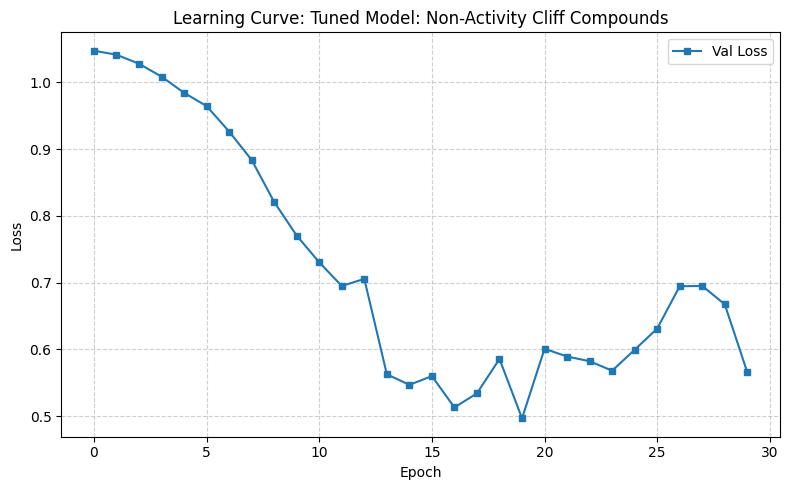

In [77]:
# --- 3. TRAIN TUNED MODEL ON NON-CLIFF DATA ---
_, _, _, metrics_dict_non_cliff, metrics_non_cliff = train_tuned_chemprop_model(
    smiles_tr_non_cliff, y_tr_non_cliff,
    smiles_val_non_cliff, y_val_non_cliff,
    smiles_non_cliff_test, y_non_cliff_test,
    "Tuned Model: Non-Activity Cliff Compounds",
    best_params_non_cliff
)

--- Overfitting Check: Non-Activity Cliffs ---


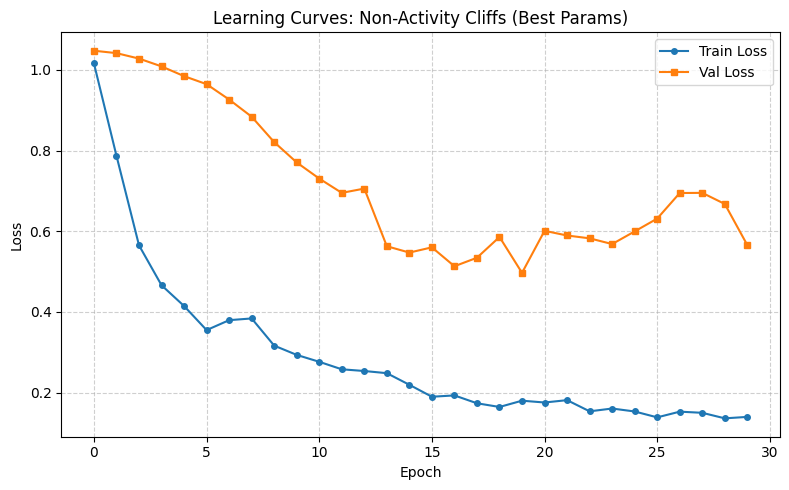

In [78]:
# --- 4. PLOT LEARNING CURVES ---
print("--- Overfitting Check: Non-Activity Cliffs ---")
plot_learning_curves(metrics_non_cliff, "Learning Curves: Non-Activity Cliffs (Best Params)")

In [72]:
#viz for most important hyperprameters since thi skeeps underfitting
import optuna.visualization as vis

# To use the visualization, we need the study object itself.
# Let's recreate the study locally or re-run a quick version if the study object isn't directly available in memory.
# Wait, I notice we only returned `study.best_params` from our functions.
# Let's write a quick modified search or just note that we need the `study` object to plot it.
# Since we didn't save the `study` object, let's re-run a fast search on non-cliff data and return the study to plot it.

def get_study_and_plot(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=20):
    print(f"\n{'='*50}\nRunning short search to get feature importance for: {study_name}\n{'='*50}")

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 100, 400)
        depth = trial.suggest_int("depth", 3, 5)
        dropout = trial.suggest_float("dropout", 0.05, 0.25)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-4, 5e-3, log=True)

        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=3, mode="min")
        trainer = pl.Trainer(
            max_epochs=15, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # Plot parameter importances
    fig = vis.plot_param_importances(study)
    fig.show()

    return study

# Run a short study to get the importance plot
study_non_cliff = get_study_and_plot(
    smiles_tr_non_cliff, y_tr_non_cliff,
    smiles_val_non_cliff, y_val_non_cliff,
    study_name="Importance Study Non-Cliff"
)


[I 2026-09-14 02:34:05,242] A new study created in memory with name: no-name-0a8564f5-e056-4bf1-89f9-ff9b9f6ab05d
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)


Running short search to get feature importance for: Importance Study Non-Cliff


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 37.0 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    204 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 31.2 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 68.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 68.4 K                                                                                               
Total estimated model params size (MB): 0.274                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.
[I 2026-09-14 02:34:07,737] Trial 0 finished with value: 0.6131498217582703 and parameters: {'hidden_size': 102, 'depth': 3, 'dropout': 0.1691589606530272, 'init_lr': 0.0002810575435396442, 'max_lr': 0.002593117556858185}. Best is trial 0 with value: 0.6131498217582703.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experimen

...

Trainable params: 147 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 147 K                                                                                                
Total estimated model params size (MB): 0.589                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.
[I 2026-09-14 02:34:55,539] Trial 18 finished with value: 0.5831803679466248 and parameters: {'hidden_size': 179, 'depth': 4, 'dropout': 0.07555700957604462, 'init_lr': 2.2081671173424957e-05, 'max_lr': 0.00043199207443289634}. Best is trial 13 with value: 0.4963068664073944.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and exp

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  102 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    380 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 57.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 160 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 160 K                                                                                                
Total estimated model params size (MB): 0.642                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.
[I 2026-09-14 02:34:58,236] Trial 19 finished with value: 0.6874533295631409 and parameters: {'hidden_size': 190, 'depth': 5, 'dropout': 0.1337723171337477, 'init_lr': 1.7225124977475968e-05, 'max_lr': 0.0002832145445752825}. Best is trial 13 with value: 0.4963068664073944.
